# Phase 3: Final Comparison — Synthetic vs. Real-World Data

## Stroke Risk Prediction Project — Full Project Synthesis

This notebook closes the loop on the entire project. We started with a synthetic dataset that produced a near-perfect model (R² ≈ 0.999), proved through hypothesis testing that this was a data artifact rather than genuine predictive power, and then validated the same modeling philosophy on a real clinical dataset to see how the picture changes.

This is not a second, separate project — it is the evidence base for one central claim about the original synthetic-data model: **its near-perfect score reflected the structure of its training data, not real predictive insight about stroke risk.**

> **Note on how this notebook relates to the others:** This notebook is a synthesis, not a pipeline. It does not re-run or import from the other notebooks — each number quoted below was computed, executed, and verified in its source notebook, then transcribed here for direct comparison:
> - Synthetic-data results (R², MAE, permutation importance) come from `EDA_01_extended.ipynb`
> - Real-data results (Recall, Precision, ROC-AUC, coefficients) come from `Phase2c_Classification_Modeling.ipynb`, which itself depends on `Phase2b_Preprocessing.ipynb`
>
> If any upstream notebook is re-run with different code or data, the figures here should be updated to match — they are not recalculated automatically.

## 1. Side-by-Side: Dataset Characteristics

In [1]:
import pandas as pd

dataset_comparison = pd.DataFrame([
    {"Aspect": "Source", "Synthetic (Phase 1)": "Generated dataset (stroke_risk_dataset.csv)", "Real (Phase 2)": "Kaggle: Healthcare Dataset Stroke Data"},
    {"Aspect": "Rows", "Synthetic (Phase 1)": "70,000", "Real (Phase 2)": "5,110"},
    {"Aspect": "Target variable", "Synthetic (Phase 1)": "Stroke Risk (%) — continuous", "Real (Phase 2)": "stroke — binary (0/1)"},
    {"Aspect": "Problem type", "Synthetic (Phase 1)": "Regression", "Real (Phase 2)": "Classification"},
    {"Aspect": "Class balance", "Synthetic (Phase 1)": "N/A (regression)", "Real (Phase 2)": "Severely imbalanced: 4.87% positive"},
    {"Aspect": "Missing data", "Synthetic (Phase 1)": "None", "Real (Phase 2)": "201 missing BMI values (3.9%), informative missingness"},
    {"Aspect": "Features", "Synthetic (Phase 1)": "15 binary symptoms + Age", "Real (Phase 2)": "Age, hypertension, heart disease, BMI, glucose, smoking, work type, etc."},
    {"Aspect": "Data quality issues", "Synthetic (Phase 1)": "None observed", "Real (Phase 2)": "Rare category (gender='Other', n=1), 30% 'Unknown' smoking status, confounded categoricals"},
])
display(dataset_comparison)

,Aspect,Synthetic (Phase 1),Real (Phase 2)
0,Source,Generated dataset (stroke_risk_dataset.csv),Kaggle: Healthcare Dataset Stroke Data
1,Rows,"70,000","5,110"
2,Target variable,Stroke Risk (%) — continuous,stroke — binary (0/1)
3,Problem type,Regression,Classification
4,Class balance,N/A (regression),Severely imbalanced: 4.87% positive
5,Missing data,None,"201 missing BMI values (3.9%), informative mis..."
6,Features,15 binary symptoms + Age,"Age, hypertension, heart disease, BMI, glucose..."
7,Data quality issues,None observed,"Rare category (gender='Other', n=1), 30% 'Unkn..."


## 2. Side-by-Side: Best Model & Performance

In [2]:
performance_comparison = pd.DataFrame([
    {"Aspect": "Best model", "Synthetic (Phase 1)": "Linear Regression", "Real (Phase 2)": "Logistic Regression (class_weight='balanced')"},
    {"Aspect": "Headline metric", "Synthetic (Phase 1)": "R² = 0.9999950", "Real (Phase 2)": "ROC-AUC = 0.837"},
    {"Aspect": "Secondary metric", "Synthetic (Phase 1)": "MAE = 0.0010", "Real (Phase 2)": "Recall (stroke) = 0.80, Precision = 0.142"},
    {"Aspect": "Naive-baseline trap", "Synthetic (Phase 1)": "Not applicable — no naive baseline issue", "Real (Phase 2)": "A model predicting 'no stroke' for everyone scores 95.1% accuracy with 2% recall"},
    {"Aspect": "Non-linear model behavior", "Synthetic (Phase 1)": "Non-linear models (Gradient Boosting, Random Forest) underperform Linear Regression", "Real (Phase 2)": "Random Forest collapses to 0% recall even with class weighting; Gradient Boosting (0.56 recall) still trails Logistic Regression (0.80 recall)"},
])
display(performance_comparison)

,Aspect,Synthetic (Phase 1),Real (Phase 2)
0,Best model,Linear Regression,Logistic Regression (class_weight='balanced')
1,Headline metric,R² = 0.9999950,ROC-AUC = 0.837
2,Secondary metric,MAE = 0.0010,"Recall (stroke) = 0.80, Precision = 0.142"
3,Naive-baseline trap,Not applicable — no naive baseline issue,A model predicting 'no stroke' for everyone sc...
4,Non-linear model behavior,"Non-linear models (Gradient Boosting, Random F...",Random Forest collapses to 0% recall even with...


**Reading this table correctly:** R² = 0.9999950 and ROC-AUC = 0.837 are not on the same scale and should never be compared as "which model is better." They answer different questions for different problem types. The real comparison that matters is *why* each number is what it is — which the next section addresses directly.

## 3. The Central Finding: Feature Importance Tells the Real Story

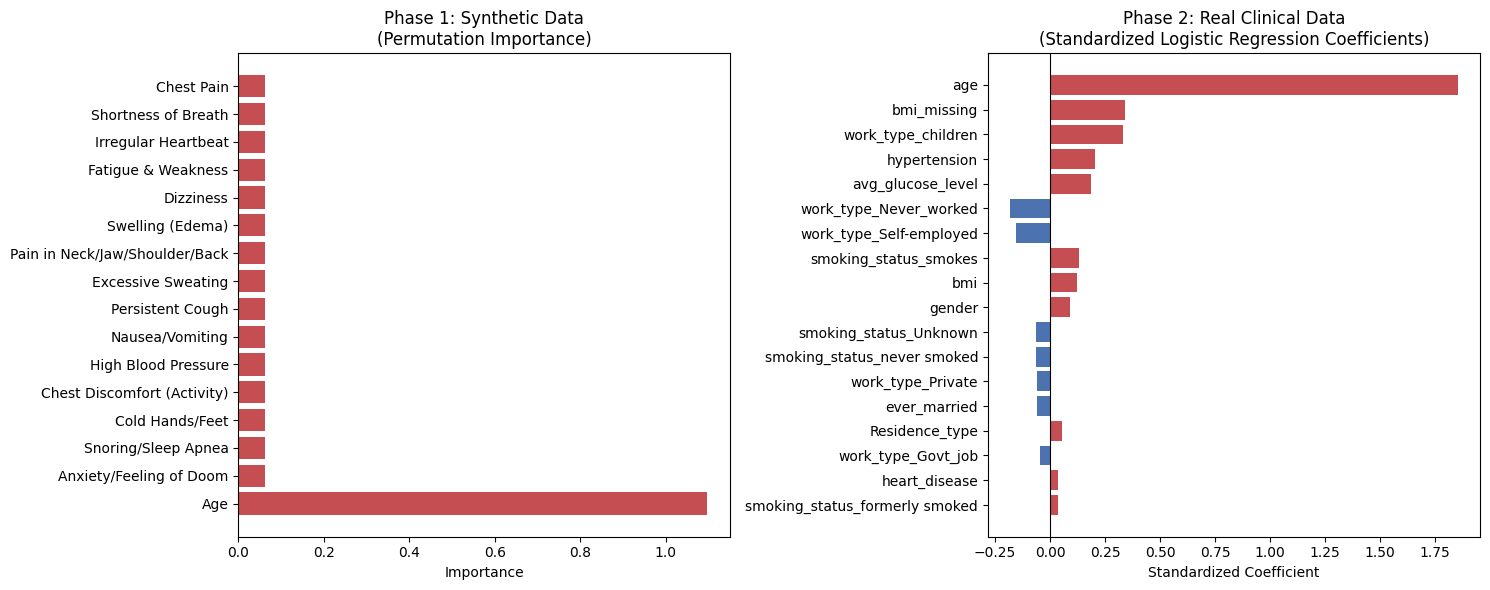

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Synthetic data: all 15 symptoms ~equal weight (from Phase 1 coefficient analysis)
synthetic_features = ['Chest Pain', 'Shortness of Breath', 'Irregular Heartbeat', 'Fatigue & Weakness',
                       'Dizziness', 'Swelling (Edema)', 'Pain in Neck/Jaw/Shoulder/Back', 'Excessive Sweating',
                       'Persistent Cough', 'Nausea/Vomiting', 'High Blood Pressure', 'Chest Discomfort (Activity)',
                       'Cold Hands/Feet', 'Snoring/Sleep Apnea', 'Anxiety/Feeling of Doom', 'Age']
synthetic_importance = [0.0622, 0.0618, 0.0619, 0.0620, 0.0620, 0.0618, 0.0619, 0.0619,
                         0.0622, 0.0618, 0.0620, 0.0620, 0.0619, 0.0623, 0.0619, 1.0961]

# Real data: standardized Logistic Regression coefficients from Phase 2c
real_features = ['age', 'bmi_missing', 'work_type_children', 'hypertension', 'avg_glucose_level',
                  'work_type_Never_worked', 'work_type_Self-employed', 'smoking_status_smokes', 'bmi',
                  'gender', 'smoking_status_Unknown', 'smoking_status_never smoked', 'work_type_Private',
                  'ever_married', 'Residence_type', 'work_type_Govt_job', 'heart_disease',
                  'smoking_status_formerly smoked']
real_importance = [1.853, 0.341, 0.332, 0.206, 0.188, -0.181, -0.156, 0.132, 0.122,
                    0.090, -0.064, -0.064, -0.060, -0.059, 0.054, -0.046, 0.036, 0.035]

axes[0].barh(synthetic_features, synthetic_importance, color='#C44E52')
axes[0].set_title('Phase 1: Synthetic Data\n(Permutation Importance)', fontsize=12)
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

colors_real = ['#C44E52' if v > 0 else '#4C72B0' for v in real_importance]
axes[1].barh(real_features, real_importance, color=colors_real)
axes[1].set_title('Phase 2: Real Clinical Data\n(Standardized Logistic Regression Coefficients)', fontsize=12)
axes[1].set_xlabel('Standardized Coefficient')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('synthetic_vs_real_importance.png', dpi=100, bbox_inches='tight')
plt.show()

**This single comparison is the heart of the project's conclusion:**

- **Left (Synthetic):** Age dominates, and then all 15 symptoms sit at an almost perfectly identical importance (~0.062 each, varying by less than 1%). This is not a clinical pattern — it is the visible fingerprint of a dataset generated by the formula `Risk ≈ 0.5×Age + 5×Symptom_Count − 9`, which we proved mathematically in Phase 1.
- **Right (Real):** Age again dominates — confirming this part of the synthetic model's signal was directionally correct — but every other feature now has a **distinct, clinically interpretable weight**: missing BMI data and being a child (low baseline risk) stand out, followed by hypertension and glucose, down to weaker contributions from marital status and government employment. Real physiology does not weight every risk factor equally, and this dataset reflects that.

The synthetic dataset's R² = 0.999 was real in the narrow sense that the model fit the formula that generated the data almost perfectly. It was not real in the sense of representing how stroke risk actually works — and this chart is the direct evidence for that distinction.

## 4. What Carried Over, and What Didn't

In [4]:
carryover = pd.DataFrame([
    {"Finding from Phase 1": "Age is the single strongest predictor", "Held up on real data?": "✅ Yes — age has by far the largest coefficient in both phases"},
    {"Finding from Phase 1": "Logistic Regression is well-suited to this problem", "Held up on real data?": "✅ Yes — Logistic Regression (with class weighting) outperformed Random Forest and Gradient Boosting on recall"},
    {"Finding from Phase 1": "Individual symptoms/features carry near-equal weight", "Held up on real data?": "❌ No — real risk factors (hypertension, heart disease, glucose) carry clearly unequal, clinically plausible weights"},
    {"Finding from Phase 1": "Non-linear models add no value over linear ones", "Held up on real data?": "✅ Yes — Random Forest and Gradient Boosting underperformed Logistic Regression in both phases, for different underlying reasons (no non-linearity to find in Phase 1; majority-class collapse under imbalance in Phase 2)"},
    {"Finding from Phase 1": "Near-perfect accuracy is achievable and trustworthy", "Held up on real data?": "❌ No — real data exposed a 95% accuracy / 2% recall trap that the synthetic data never could, since it had no class imbalance problem to hide behind"},
])
display(carryover)

,Finding from Phase 1,Held up on real data?
0,Age is the single strongest predictor,✅ Yes — age has by far the largest coefficient...
1,Logistic Regression is well-suited to this pro...,✅ Yes — Logistic Regression (with class weight...
2,Individual symptoms/features carry near-equal ...,"❌ No — real risk factors (hypertension, heart ..."
3,Non-linear models add no value over linear ones,✅ Yes — Random Forest and Gradient Boosting un...
4,Near-perfect accuracy is achievable and trustw...,❌ No — real data exposed a 95% accuracy / 2% r...


**Interesting nuance:** the original project's README claimed Logistic Regression was the best model with ROC-AUC ≈ 0.93 — a claim that didn't match the actual synthetic-data notebook (which used Linear Regression for a regression target). It turns out that claim becomes *true*, almost by coincidence, once real classification data is introduced: Logistic Regression genuinely is the strongest model here, just for reasons the original synthetic-data analysis could never have demonstrated.

## 5. Final Conclusion

This project followed a complete, evidence-driven arc:

1. **Built and evaluated a regression model on synthetic data**, reaching R² ≈ 0.999.
2. **Investigated that suspiciously high score** instead of accepting it, and proved — through coefficient analysis, permutation importance, engineered interaction terms, and a deliberate non-linear modeling test — that the synthetic dataset was generated by a simple additive formula (`Risk ≈ 0.5×Age + 5×Symptom_Count − 9`), which is why every symptom carried equal weight and why no model could find more signal than that formula contained.
3. **Validated the modeling approach on real clinical data** (Kaggle's stroke dataset), confronting genuinely different challenges — severe class imbalance, informative missing data, and confounded categorical variables — that the synthetic data never presented.
4. **Confirmed that the core finding generalizes (age dominates; Logistic Regression is well-suited) while the equal-weighting artifact does not** — real risk factors carry distinct, clinically plausible importance, which is the clearest possible evidence that the synthetic model's uniform symptom weighting was a property of the data, not of reality.

**The headline takeaway:** a model's evaluation metric is only as meaningful as the data it was computed on. R² ≈ 0.999 was a true statement about how well Linear Regression fit a formula — and a misleading one about stroke risk. Validating that distinction, rather than asserting it, is what this two-phase analysis was built to demonstrate.